# **Lab 4. IMU with Raspberry Pi 5 (GY-521 / MPU6050)**


Teamwork: 4 Teams


## **Objectives**
* Connect the **MPU6050** (GY-521) via **I2C** and read raw accelerometer + gyroscope data.
* Publish IMU data as standard ROS 2 messages (`sensor_msgs/Imu`).
* Filter IMU raw data through Madgwick filter
* Put filtered IMU data into Sensor Fusion (EKF)
* Visualize and record experiments (RViz2, rqt_plot)
* Extra task:
  * Prepare a ROS2 driver for the BLDC motor
  * Publish wheel odometry
  * Fuse wheel odometry with IMU in Sensor Fusion (EKF)


## **Hardware**
* Raspberry Pi 5
* GY-521 (MPU6050) module
* 4 wires: 3V3, GND, SDA, SCL
* MicroSD
* Power supply for Rpi
* Your laptop

### Wiring (recommended)
* **VCC → 3V3**
* **GND → GND**
* **SDA → GPIO2 (SDA1)**
* **SCL → GPIO3 (SCL1)**

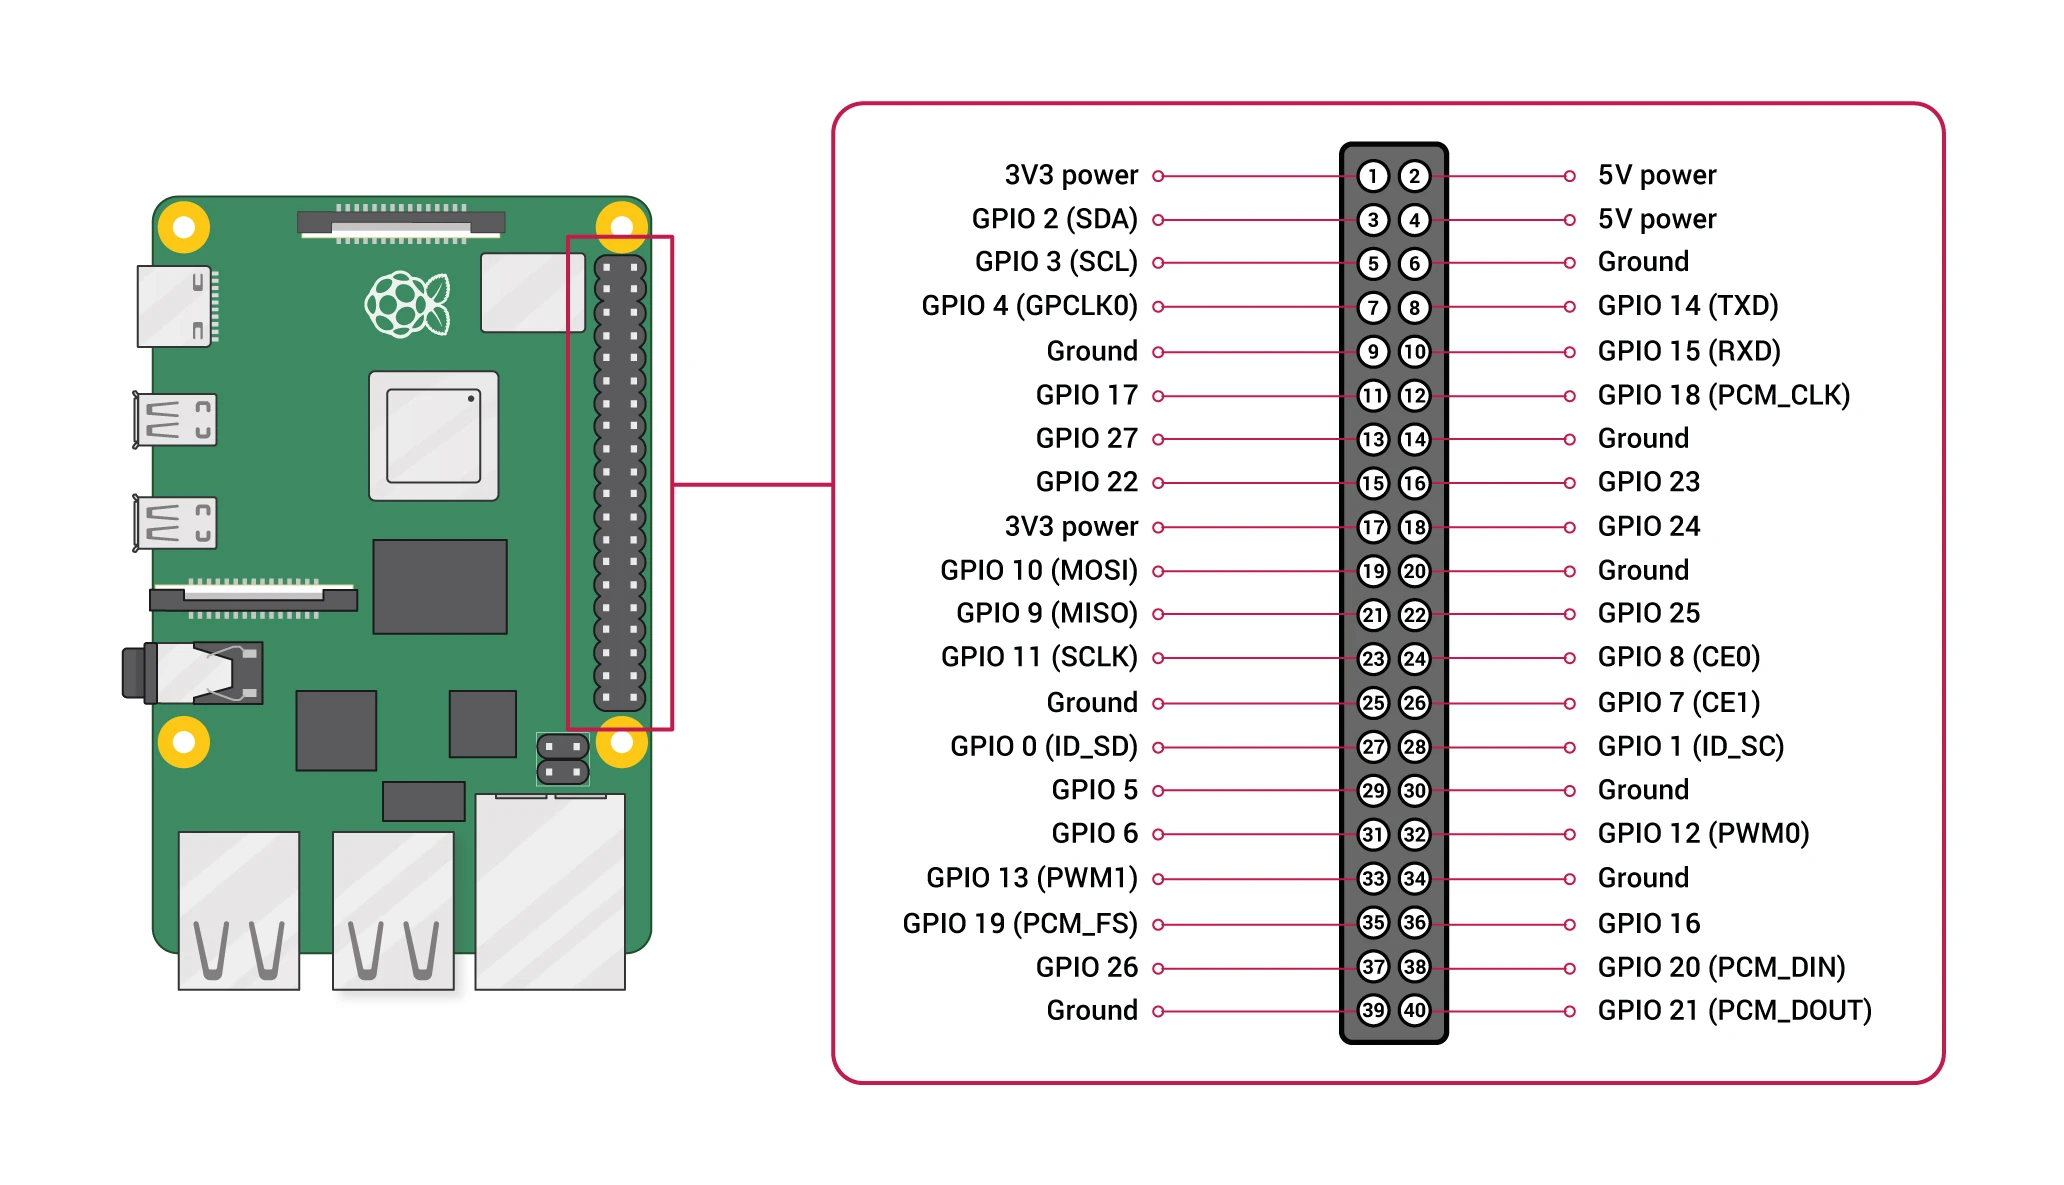

## **What you need to do**


Task 1. Prepare Raspberry Pi 5
### 1) Prepare the microSD with Raspberry Pi OS (using Raspberry Pi Imager)

1. Install [**Raspberry Pi Imager**](https://www.raspberrypi.com/software/)
2. Insert the microSD card (recommended: 32 GB+).
3. Open Imager

You can use just comand in terminal:
```bash
rpi-imager
```
4. Setup OS
   * **Choose OS**: *Raspberry Pi OS (64-bit)* (Lite is OK; Desktop also OK).
   * **Choose Storage**: select the microSD card.
5. Click the **gear icon (OS Customisation)** and set:

   * **Hostname**: e.g. `<team_name>`
   * **Enable SSH**: ON

     * Prefer **Password authentication** for initial setup (you can switch to keys later).
   * **Username/Password**: set a known pair (write it down).
   * **Configure Wi-Fi**: ON
     * **SSID**: your Wi-Fi name e.g. `InnoRobotics`
     * **Password**: Wi-Fi password e.g. `jJshs54hO`
     * **Wi-Fi country**: set correctly (required for regulatory domain, `RU`)
   * **Locale/Timezone/Keyboard**: set appropriately.
6. Save, then click **Write**.





### 2) Boot the Raspberry Pi 5

1. Insert the microSD into the Raspberry Pi 5.
2. Connect:

   * Ensure Raspberry Pi is within Wi-Fi coverage
   * Monitor/keyboard only if needed for troubleshooting (headless should work if SSH was enabled in Imager).
3. Power the Raspberry Pi 5 by Special Power



3) Wi-Fi SSH connection

Use one of these ways to connect:

#### Option 1 (preferred): mDNS hostname

From your computer:

```bash
ssh <username>@<team_name>.local
```

#### Option 2: Find the IP address, then SSH

Ways to find the IP:

* Check the router’s DHCP client list for `<team_name>`
* From macOS/Linux (same Wi-Fi network), scan quickly:

  * macOS:

    ```bash
    arp -a
    ```
  * Linux:

    ```bash
    ip neigh
    ```

Then SSH:

```bash
ssh <username>@<pi_ip>
```

#### Option 3: Cry (Pi imager don't want to work properly)

* Connect the hardware: Connect a monitor, keyboard, and mouse to the Pi and turn it on.
* Do all instuctions in UI
* Open a terminal: After the system boots, open a terminal window.
*Run the configuration tool: Enter the command:
```bash
sudo raspi-config
```
* Find the desired option: In the menu that appears, use the arrow keys on your keyboard to navigate to Interfacing Options.
* Enable SSH: Select SSH. The system will ask if you want to enable the SSH server. Confirm by selecting <Yes>.

### 4) First login and base system update

After SSH login:

```bash
sudo apt-get update
sudo apt-get -y full-upgrade
sudo reboot
```

Reconnect via SSH after reboot.



### 5) Install Docker Engine on Raspberry Pi OS (Debian-based, 64-bit)

1. Install prerequisites:

```bash
sudo apt-get update
sudo apt-get install -y ca-certificates curl gnupg
```

2. Add Docker’s official GPG key:

```bash
sudo install -m 0755 -d /etc/apt/keyrings
curl -fsSL https://download.docker.com/linux/debian/gpg | sudo gpg --dearmor -o /etc/apt/keyrings/docker.gpg
sudo chmod a+r /etc/apt/keyrings/docker.gpg
```

3. Add the Docker repository:

```bash
echo \
  "deb [arch=$(dpkg --print-architecture) signed-by=/etc/apt/keyrings/docker.gpg] https://download.docker.com/linux/debian \
  $(. /etc/os-release && echo "$VERSION_CODENAME") stable" | \
  sudo tee /etc/apt/sources.list.d/docker.list > /dev/null
```

4. Install Docker:

```bash
sudo apt-get update
sudo apt-get install -y docker-ce docker-ce-cli containerd.io docker-buildx-plugin docker-compose-plugin
```

5. Enable and start Docker:

```bash
sudo systemctl enable docker
sudo systemctl start docker
```

6. Allow running Docker without `sudo` (recommended):

```bash
sudo usermod -aG docker $USER
newgrp docker
```

7. Test:

```bash
docker run --rm hello-world
docker version
docker compose version
```

8. Docker compose
Make folder for work:
```bash
mkdir lab
```

6. Docker compose
#### On your machine!!
Transfer docker-compose.yaml from your machine to Pi:
```bash
scp <path_to_file>/docker-compose.yaml <username>@<pi_ip>:/home/<username>/lab
```

### Task 2 — Enable I2C + verify the sensor
#### !!!Again on Rpi terminal!!!!
1. Enable I2C:
```bash
sudo raspi-config   # Interface Options -> I2C -> Enable
sudo reboot
```
2. Detect device:
```bash
sudo i2cdetect -y 1
```

### Wiring
* **VCC → 3V3**
* **GND → GND**
* **SDA → GPIO2 (SDA1)**
* **SCL → GPIO3 (SCL1)**

Default I2C address is **0x68**. If AD0 is pulled high → **0x69**.

**Checkpoint (report):** screenshot of `i2cdetect` output.


### Let's check our IMU

Add new .py file in `lab` folde and open it in nano
```bash
touch test_imu.py
nano test_imu.py
```

Installation of nano may be required:
```bash
sudo apt install nano
```

Paste following code:

> *hint for nano:*
>
> `Ctrl + Shift + v` - paste in terminal
>
> `Ctrl + X` - exit nano
>
> `Ctrl + S` - save file

In [ ]:
# Quick check without ROS 2
# Reads accel/gyro once and prints values in SI units.
import math
import time

try:
    from smbus2 import SMBus
except Exception:
    from smbus import SMBus

ADDR = 0x68
BUS = 1

REG_PWR_MGMT_1 = 0x6B
REG_ACCEL_XOUT_H = 0x3B

def to_int16(msb, lsb):
    v = (msb << 8) | lsb
    if v & 0x8000:
        v = -((0xFFFF - v) + 1)
    return v

with SMBus(BUS) as bus:
    while True:
        bus.write_byte_data(ADDR, REG_PWR_MGMT_1, 0x00)  # wake up
        time.sleep(0.05)
        b = bus.read_i2c_block_data(ADDR, REG_ACCEL_XOUT_H, 14)

        ax = to_int16(b[0], b[1])
        ay = to_int16(b[2], b[3])
        az = to_int16(b[4], b[5])
        gx = to_int16(b[8], b[9])
        gy = to_int16(b[10], b[11])
        gz = to_int16(b[12], b[13])

        # default ranges: ±2g (16384 LSB/g), ±250 dps (131 LSB/dps)
        g = 9.80665
        ax_ms2 = ax * (g / 16384.0)
        ay_ms2 = ay * (g / 16384.0)
        az_ms2 = az * (g / 16384.0)

        gx_rads = gx * ((math.pi / 180.0) / 131.0)
        gy_rads = gy * ((math.pi / 180.0) / 131.0)
        gz_rads = gz * ((math.pi / 180.0) / 131.0)

        print("accel [m/s^2]:", ax_ms2, ay_ms2, az_ms2)
        print("gyro  [rad/s]:", gx_rads, gy_rads, gz_rads)


Useful links:
* [MPU-6050 datasheet](https://invensense.tdk.com/wp-content/uploads/2015/02/MPU-6000-Datasheet1.pdf)
* [GY-521 docs](https://www.google.com/url?sa=t&source=web&rct=j&opi=89978449&url=https://mysii.gorriens.net/images/arduino/capteurs/gy-521_mpu-6050_3-axis_gyroscope_and_acceleration_sensor_en.pdf&ved=2ahUKEwjshN732PGSAxUBVEEAHaD3PGkQFnoECCEQAQ&usg=AOvVaw1egZtQ5v2pOJWTceFNuAe5)

> *note:* MPU-6050 is the actual sensor chip and GY-521 is board with this chip


**Checkpoint (report):** screenshot of code output

## Task 3. Create a ROS2 package and implement an IMU reader node (GY-521 / MPU6050)

!!All next steps should be in container!!

### 3.1 Goal

You need to create your own ROS2 Python package and implement a node that reads **accelerometer + gyroscope** from **MPU6050** over **I2C** and publishes `sensor_msgs/msg/Imu`.

Minimal requirement:

* Read raw IMU registers via I2C.
* Convert to SI units.
* Publish to a ROS2 topic at a fixed rate.

### Node interface

**Publishes**

* Topic: `/imu/raw`
* Type: `sensor_msgs/msg/Imu`
* Fields required:

  * `header.stamp`, `header.frame_id`
  * `linear_acceleration.{x,y,z}` in `m/s^2`
  * `angular_velocity.{x,y,z}` in `rad/s`
  * Orientation is not required (set orientation covariance to `-1` to indicate “not provided”).

**Subscribes**

* None

### 3.2 Parameters (recommended)

* `i2c_bus` (int, default `1`)
* `i2c_address` (int, default `0x68`)
* `publish_rate_hz` (float, default `100.0`)
* `frame_id` (string, default `imu_link`)


### 3.3 Create a package and build

Create a Python package in your workspace:

```bash
cd ~/ros2_ws/src
ros2 pkg create <pkg_team_name> --build-type ament_python --license Apache-2.0 \
  --dependencies rclpy sensor_msgs \
```

### 3.4 Implement the node (file layout)

Create a new Python file:

```bash
touch ~/ros2_ws/src/<pkg_team_name>/<pkg_team_name>/mpu6050_node.py
```

Recommended structure inside `mpu6050_node.py` (with I2C bus explanation)

* Open the I2C bus (`/dev/i2c-<bus_id>`) using `smbus2`.

  * I2C is a two-wire serial bus:

    * `SDA` (data line) and `SCL` (clock line)
  * The Raspberry Pi acts as an I2C **master**. The MPU6050 acts as an I2C **slave** device.
  * Each slave has a 7-bit address. For GY-521 it is usually:

    * `0x68` if `AD0 = 0`
    * `0x69` if `AD0 = 1`
  * Every transaction follows the same pattern:

    1. Master sends **START**
    2. Master sends the **7-bit slave address + R/W bit**
    3. Slave responds with **ACK** (Acknowledge, wheter it read data and continue connection)
    4. Master sends a **register address** (for register-based devices like MPU6050)
    5. Slave ACK again
    6. Master either:

       * writes data bytes (write transaction), or
       * issues a repeated START and reads bytes (read transaction)
    7. Master sends **STOP**
  * In practice, libraries such as `smbus2` implement these patterns for you as “write register” and “read block” operations.

* Wake up the MPU6050 by writing to its power management register.

  * The MPU6050 has an internal register map. You write to it over I2C using “register address + data”.
  * `PWR_MGMT_1 = 0x6B` controls sleep mode.
  * Writing `0x00` clears the sleep bit and enables measurements:

    * I2C write sequence conceptually:

      * START → address(0x68, write) → ACK → register(0x6B) → ACK → data(0x00) → ACK → STOP

* Read accelerometer and gyroscope samples using sequential register reads.

  * Sensor measurements are stored as signed 16-bit values split into two 8-bit registers: High byte then Low byte:

    * 0x3B..0x40: Accelerometer (6 bytes):

      * ACCEL_XOUT_H 0x3B
      * ACCEL_XOUT_L 0x3C
      * ACCEL_YOUT_H 0x3D
      * ACCEL_YOUT_L 0x3E
      * ACCEL_ZOUT_H 0x3F
      * ACCEL_ZOUT_L 0x40

    * 0x41..0x42: Temperature (2 bytes):
      * TEMP_OUT_H 0x41
      * TEMP_OUT_L 0x42

    * 0x43..0x48: Gyroscope (6 bytes):

      * GYRO_XOUT_H 0x43
      * ...
      * GYRO_ZOUT_L 0x48

  * A typical “read block” uses:

    1. Write the start register address (`0x3B` or `0x43`) to set the internal register pointer
    2. Repeated START
    3. Read N bytes (6 bytes) in one transaction
  * This “sequential read” is important because:

    * it is faster than reading each register separately
    * all 6 bytes come from a consistent time window (less risk of mixing samples)

* Convert raw register values into physical units.

  * Convert two bytes `(hi, lo)` to a signed 16-bit integer:

    * `raw = int16((hi << 8) | lo)`
  * Accelerometer conversion (default full-scale ±2g):

    * datasheet sensitivity is `16384 LSB/g`
    * `accel_g = raw / 16384.0`
    * `accel_mps2 = accel_g * 9.80665`
  * Gyroscope conversion (default full-scale ±250 deg/s):

    * datasheet sensitivity is `131 LSB/(deg/s)`
    * `gyro_dps = raw / 131.0`
    * `gyro_rads = gyro_dps * (pi/180)`

* Publish the converted values as `sensor_msgs/msg/Imu`.

  * Put `linear_acceleration` in `m/s^2`.
  * Put `angular_velocity` in `rad/s`.
  * Set `orientation_covariance[0] = -1.0` to indicate orientation is not provided by this node.


### 3.5 Do not forget to add an entry point (so `ros2 run` works)

### 3.6 Build:

```bash
cd ~/ros2_ws
colcon build
source install/setup.bash
```

### 3.7 Run and verify

Run:

```bash
ros2 run <pkg_team_name> <executable>
```

Check message output(in another terminal):

```bash
ros2 topic echo --once /imu/raw
```

Check publish rate:

```bash
ros2 topic hz /imu/raw
```


**Checkpoint (report):**

* Screenshot or pasted output of:

  * `ros2 topic echo -once /imu/raw`
  * `ros2 topic hz /imu/raw`
* Short explanation:

  * which units are published?
  * which fields are not provided?
  * expected behavior at rest, what do you see?


## Task 4. Running `imu_filter_madgwick`

IMU data requires filtering; there are different approaches, but we want to offer you one of the most effective ones at the moment - Madgwick filter

- [Docs for Madgwick filter](https://wiki.ros.org/imu_filter_madgwick)
- [Habr about Madgwick filter](https://habr.com/ru/articles/255661/)
- [Common way to process IMU data (Habr, Ru)](https://habr.com/ru/articles/491476/)
- [Common way to process IMU data (mathworks, En)](https://www.mathworks.com/help/fusion/ref/imufilter-system-object.html#mw_0c74d579-fceb-4401-934d-65b96f2289a8)

### 4.1 Start your raw IMU publisher

Your node must publish:

* Topic: `/imu/raw`
* Type: `sensor_msgs/msg/Imu`
* Valid timestamps in `header.stamp`
* Non-empty `header.frame_id` (recommended: `imu_link`)

Quick check:

```bash
ros2 topic echo --once /imu/raw
```

### 4.2 Run Madgwick with correct remaps and parameters

By default, the node expects raw IMU on `imu/data_raw` and publishes filtered IMU on `imu/data`, so you must remap input/output.

Recommended command for MPU6050 (no mag), no TF publication (safe when EKF is also running in next steps):

```bash
ros2 run imu_filter_madgwick imu_filter_madgwick_node --ros-args \
  -r imu/data_raw:=/imu/raw \
  -p use_mag:=false \
  -p publish_tf:=false \
  -p publish_debug_topics:=true \
```

> *Notes*:
>`publish_tf:=false` avoids TF conflicts with EKF/static transforms

### 4.3 Verify outputs

Filtered IMU:

```bash
ros2 topic echo --once /imu/madgwick
```

Debug RPY (only if `publish_debug_topics:=true`):

```bash
ros2 topic echo --once /imu/rpy/filtered
```


## Task 5. Run EKF from raw IMU and visualize in RViz2

[ROS2 EKF docs](https://docs.ros.org/en/melodic/api/robot_localization/html/state_estimation_nodes.html)

### 5.1 Preconditions

* Your IMU node and Madgwick filter are running and publishes as a result:

  * Topic `/imu/data`
  * Type `sensor_msgs/msg/Imu`
  * `header.frame_id` set (recommended: `imu_link`)
* Check:

### 5.2 Create EKF config file

Create a folder for configs:

```bash
mkdir -p ~/ros2_ws/src/<your_team_name>/config
```

Create `~/ros2_ws/src/<your_team_name>/config/ekf_imu.yaml` with the following content:

```yaml
ekf_filter_node:
  ros__parameters:

    # --- Filter execution ---
    frequency: 50.0              # EKF update rate (Hz). Must be <= IMU publish rate.
    sensor_timeout: 0.1          # If sensor data is older than this (s), it is treated as stale.
    two_d_mode: false            # false: full 3D state (roll/pitch/yaw). true: constrain motion to planar

    # --- TF publication ---
    publish_tf: true             # If true, EKF publishes a TF transform world_frame -> base_link_frame.

    # --- Frame naming (TF tree) ---
    map_frame: map               # Global/map frame name (used mainly for dual-EKF setups)
    odom_frame: odom             # Local continuous frame. This is typically the world frame.
    base_link_frame: base_link    # The robot body frame whose pose EKF outputs (must exist in TF)
    world_frame: odom            # The frame used as the parent for the published transform (world_frame -> base_link_frame).

    # --- IMU input ---
    imu0: /imu/data               # Input IMU topic (sensor_msgs/Imu). Must have correct header.stamp and frame_id.
    imu0_config: [               # Which IMU variables are fused into the EKF state (15 booleans, in this exact order):
      false, false, false,       # 1) x, y, z position
      false, false, false,       # 2) roll, pitch, yaw orientation
      false, false, false,       # 3) x, y, z linear velocity
      true,  true,  true,        # 4) roll, pitch, yaw angular velocity (gyro rates)
      false, false, false        # 5) x, y, z linear acceleration
    ]

    imu0_differential: false     # false: use measurements directly. true: treat as delta measurements
    imu0_relative: false         # false: absolute measurement interpretation. true: treat as relative to the first measurement.
    imu0_queue_size: 20          # Subscriber queue size for the IMU topic.
    imu0_remove_gravitational_acceleration: true  # If true, subtract gravity from linear acceleration before fusion
```

### 5.3 Run EKF

Without a proper transformation tree, the ROS2 system will not be able to process the data correctly. EKF will not start at all, but it will not complain about it, you just need to know this fact :)

Terminal 3 (TF):
```bash
ros2 run tf2_ros static_transform_publisher 0 0 0 0 0 0 base_link imu_link
```

Terminal 4 (EKF):
```bash
source ~/ros2_ws/install/setup.bash
ros2 run robot_localization ekf_node --ros-args --params-file ~/ros2_ws/src/<your_team_name>/config/ekf_imu.yaml
```

### 5.4 Verify EKF outputs

```bash
ros2 topic list | grep -E "odometry|tf"
ros2 topic echo -once /odometry/filtered
ros2 run tf2_ros tf2_echo odom imu_link
```

Expected:

* `/odometry/filtered` exists
* `odom -> imu_link` transform exists (`publish_tf: true`)

### 5.5 RViz2 visualization

Run:

```bash
rviz2
```

In RViz2:

1. Set **Fixed Frame** to `odom`
2. Add display **TF**
3. Add display **Odometry**

   * Topic: `/odometry/filtered`

This will show a stable TF tree and an orientation-driven pose for visualization





### 5.6 Important note about covariances

### Why covariances are required

`EKF` uses measurement covariances as “trust weights”.

* **Small covariance** - EKF trusts this sensor a lot.
* **Large covariance** - EKF trusts this sensor less.

If you set all zeros, the EKF interprets it as “almost perfect sensor” and will over-trust it.

### What to set in `sensor_msgs/Imu`

You have three covariance matrices (3×3 each, stored as a 9-element array):

* `angular_velocity_covariance`
* `linear_acceleration_covariance`
* `orientation_covariance`

For a raw MPU6050 node (no orientation estimate):

* **Do not provide orientation**:
  `msg.orientation_covariance[0] = -1.0`
  This is a ROS convention meaning “orientation not provided”.

### Practical values to start with

* `angular_velocity_covariance` diagonal: `1e-3` to `1e-2`
* `linear_acceleration_covariance` diagonal: `1e-2` to `1e-1`

**Checkpoint (report):**

* Video demonstrating the IMU rotation in rviz2
* Fix IMU with Z axis up or down, what's happening, why?
  * Hint: gravity helps find the tilt in Roll and Pitch, what is missing for Yaw?
* Try to add linear movement by change of `imu0_config`, what's happening, why?
* Link to your GitHub repo in report

## Exta Task (5 points)

### Common idea: ROS2 motor driver + cmd_vel controller + wheel odom + EKF fusion

Reference implementation to use: [`valeriaskvo/gyems_motor_control`](https://github.com/valeriaskvo/gyems_motor_control)

### 6.1 Deliverables

1. ROS2 package `gyems_ros2` with two nodes and one EKF config.
2. Motor driver node

   * Subscribes to a motor command topic
   * Publishes motor rotation angle
3. Base controller node

   * Subscribes to `/cmd_vel`
   * Publishes wheel commands for motor driver
   * Publishes wheel odometry
4. EKF configured to fuse IMU and wheel odometry


### 6.2 Package skeleton

Create a new package:

```bash
cd ~/ros2_ws/src
ros2 pkg create gyems_ros2_<team_name> --build-type ament_python --license Apache-2.0 \
  --dependencies rclpy std_msgs geometry_msgs nav_msgs sensor_msgs tf2_ros \
```

Add folders:

```bash
cd ~/ros2_ws/src/gyems_ros2/gyems_ros2
mkdir -p valeriaskvo_gyems_motor_control
```

Clone the repo code into `valeriaskvo_gyems_motor_control` (copy or git submodule). The code provides a SocketCAN bus wrapper and a `GyemsDRC` motor class.

---

### 6.3 Node 1: Motor driver node skeleton

File: `gyems_ros2/gyems_motor_driver_node.py`

Topics

* Sub `/motor/command`: `std_msgs/Float64`
* Pub `/motor/angle`: `std_msgs/Float64`

Parameters

* `interface`: default `can0`
* `device_id`: default `0x141`
* `bitrate`: default `1000000`
* `control_mode`: one of `current`, `speed`, `angle`
* `publish_rate_hz`: default `100`

---

### 6.4 Node 2: cmd_vel to wheel commands + wheel odometry skeleton

Assume robot on a rail with a single motor.

File: `gyems_ros2/rail_controller_node.py`

Topics

* Sub `/cmd_vel`: `geometry_msgs/Twist`
* Sub `/motor/angle`: `std_msgs/Float64`
* Pub `/motor/command`: `std_msgs/Float64`
* Pub `/wheel/odometry`: `nav_msgs/Odometry`
* Pub TF `odom -> base_link`: `tf2_ros.TransformBroadcaster`

Parameters

* `wheel_radius`: in meters
* `cmd_mode` one of `speed`, `current`
* `odom_frame`: default `odom`
* `base_link_frame`: default `base_link`
* `publish_rate_hz`: default `50`

---

## EKF configuration skeleton: fuse IMU + wheel odom

Use `robot_localization ekf_node`. Wheel odom provides pose and IMU provides orientation

Create `config/ekf_imu_wheel.yaml` and configure

---


## Validation checklist

* `ros2 topic echo -once /motor/angle` changes when motor rotates
* `ros2 topic echo -once /wheel/odometry` updates while motors rotate
* `ros2 topic echo -once /odometry/filtered` exists
* `ros2 run tf2_ros tf2_echo odom base_link` works
* RViz Fixed Frame `odom`, show TF and Odometry `/odometry/filtered`

